<a href="https://colab.research.google.com/github/victorgalvao7/checkpoint02-SERS-1CCPQ/blob/main/AULA_06_SERS_ML_ENERGIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##MODELO DE CLASIFAÇÃO

Treinar um modelo preditivo de classificação utilizando o algoritmo Regressão Logística (Logistic Regression do sklearn) para prever se a rede elétrica está instável ou estável com base nos atributos fornecidos na fonte.

Fonte: https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

In [2]:
# Preparação do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Algoritmo de regressão logítica
from sklearn.linear_model import LogisticRegression
# Função que permite separação de treino e teste
from sklearn.model_selection import train_test_split
# Métricas para classificação
from sklearn.metrics import accuracy_score
# Matriz de confusão
from sklearn.metrics import confusion_matrix

In [3]:
# Carregar os dados e criar o dataframe
dados = pd.read_csv("https://raw.githubusercontent.com/victorgalvao7/checkpoint02-SERS-1CCPQ/refs/heads/main/Data_for_UCI_named.csv")
dados.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [4]:
# Inspeção básicas
dados.shape

(10000, 14)

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [7]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [6]:
# Estatíticas descritivas
# Somente atributos categóricos
dados.describe(include='object')


,stabf
count,10000
unique,2
top,unstable
freq,6380


In [10]:
# Quais as classes tenos no atributo 'stabf'?
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [11]:
# Quantos registros temos de cada classe em 'stabf'?
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [18]:
# Dados de entrada X (maiúsculo) --------> Features --------> DataFrame
# Varíaveis indepedentes
X = dados.drop(['stab','stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [14]:
dados['stabf'] = dados['stabf'].replace({'unstable': 'INSTÁVEL', 'stable': 'ESTÁVEL'})


In [15]:
# Dados de saída y (minúsculo) ------> Target -------> o qye vamos prever
# Variável depedente
y = dados ['stabf']
y

,stabf
0,INSTÁVEL
1,ESTÁVEL
2,INSTÁVEL
3,INSTÁVEL
4,INSTÁVEL
...,...
9995,INSTÁVEL
9996,ESTÁVEL
9997,ESTÁVEL
9998,INSTÁVEL


In [27]:
# Separação de dados para treino e para teste (train_test_split)
# X_train, X_test, y-train, y_test
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


In [19]:
X.shape[0]

10000

In [20]:
X_train.shape[0]

7000

In [21]:
X_test.shape[0]

3000

In [22]:
# Instanciando o modelo com base no algoritmo Logistic Regression
modelo = LogisticRegression()

In [23]:
# Treinando o modelo
modelo.fit(X_train, y_train)

LogisticRegression()

In [28]:
# Gerando as probabilidades
probabilidades = modelo.predict_proba(X_test)
probabilidades[:50]

array([[0.04275076, 0.95724924],
       [0.05253553, 0.94746447],
       [0.27950907, 0.72049093],
       [0.98071875, 0.01928125],
       [0.67050507, 0.32949493],
       [0.58369123, 0.41630877],
       [0.70842366, 0.29157634],
       [0.02048093, 0.97951907],
       [0.04179796, 0.95820204],
       [0.74345398, 0.25654602],
       [0.05533052, 0.94466948],
       [0.43933965, 0.56066035],
       [0.52585142, 0.47414858],
       [0.20441781, 0.79558219],
       [0.01686508, 0.98313492],
       [0.24049878, 0.75950122],
       [0.42654485, 0.57345515],
       [0.18889533, 0.81110467],
       [0.44077106, 0.55922894],
       [0.29343944, 0.70656056],
       [0.08059958, 0.91940042],
       [0.11533044, 0.88466956],
       [0.17807534, 0.82192466],
       [0.77016367, 0.22983633],
       [0.33245274, 0.66754726],
       [0.28054652, 0.71945348],
       [0.58571669, 0.41428331],
       [0.48227649, 0.51772351],
       [0.68167454, 0.31832546],
       [0.92548237, 0.07451763],
       [0.

In [29]:
# Gerando as previsões
y_predict = modelo.predict(X_test)
y_predict[:50]

array(['INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL'],
      dtype=object)

In [31]:
# Acurácia do modelo
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f"A acurácia do modelo é de {acuracia:.2f}%")

A acurácia do modelo é de 81.03%


In [33]:
# Gerar matriz de confusão com matplotlib e heatmap
matriz_confusao = confusion_matrix(y_test, y_predict)
matriz_confusao

array([[ 744,  317],
       [ 252, 1687]])

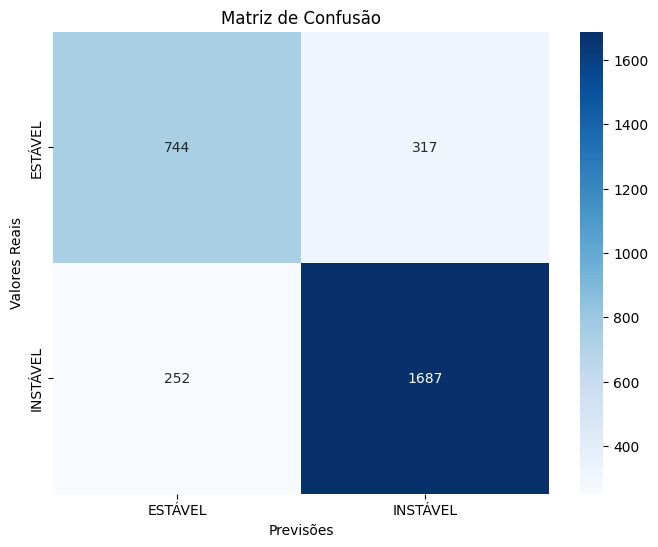

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()